# CatBoost Sepsis Prediction — ICH Patients
**Reference:** Liu et al., JMIR 2025

### Pipeline overview
1. Load raw data & aggregate to one row per patient (first 24 h)
2. Column mapping + SOFA / SAPSII / MV proxy derivation
3. Drop columns with >20% missing → MICE imputation
4. Class imbalance correction (`scale_pos_weight`)
5. Boruta feature selection (balanced RF)
6. Spearman collinearity removal (r > 0.8)
7. 70 / 30 stratified split
8. Feature reduction to top 8
9. 10-fold cross-validation
10. Final CatBoost training (iterations = 50, lr = 0.1, depth = 10)
11. Evaluation — AUC + 95 % CI (bootstrap), Youden threshold, all metrics
12. ROC / DCA / Precision-Recall curves
13. Confusion matrix
14. SHAP summary plot (Fig 3A) + waterfall plot (Fig 3B)
15. Save model & outputs

In [1]:
# ── Install required packages (run once) ──────────────────────────────────
import subprocess, sys
for pkg in ['catboost', 'boruta', 'shap']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)
print('All packages ready')

All packages ready


In [2]:
# ── Imports & hyperparameters ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings, time
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from catboost import CatBoostClassifier
from boruta import BorutaPy
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# ── Hyperparameters ───────────────────────────────────────────────────────
LEARNING_RATE = 0.1
DEPTH         = 10
ITERATIONS    = 50
TEST_SIZE     = 0.30   # 70/30 split
CV_FOLDS      = 10
N_BOOTSTRAP   = 1000   # bootstrap resamples for 95% CI
scale_pos_weight = 20

print('Imports OK')
print(f'  CatBoost  : {__import__("catboost").__version__}')
print(f'  Seed      : {SEED}')
print()
print('Hyperparameters:')
print(f'  learning_rate = {LEARNING_RATE}')
print(f'  depth         = {DEPTH}')
print(f'  iterations    = {ITERATIONS}')
print(f'  split         = {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}')
print(f'  CV folds      = {CV_FOLDS}')

Imports OK
  CatBoost  : 1.2.10
  Seed      : 42

Hyperparameters:
  learning_rate = 0.1
  depth         = 10
  iterations    = 50
  split         = 70/30
  CV folds      = 10


In [3]:
# ── STEP 1 — Load Raw Data ────────────────────────────────────────────────
DATA_PATH = '/content/Dataset.csv'   # ← update path if needed

df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape : {df_raw.shape}')
print(f'Columns   : {df_raw.columns.tolist()}')
print()
print(df_raw.head(3).to_string())

Raw shape : (73543, 44)
Columns   : ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

   Unnamed: 0  Hour    HR  O2Sat  Temp  SBP   MAP  DBP  Resp  EtCO2  BaseExcess  HCO3  FiO2  pH  PaCO2  SaO2  AST  BUN  Alkalinephos  Calcium  Chloride  Creatinine  Bilirubin_direct  Glucose  Lactate  Magnesium  Phosphate  Potassium  Bilirubin_total  TroponinI  Hct  Hgb  PTT  WBC  Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  SepsisLabel  Patient_ID
0           0     0   NaN    NaN   NaN  NaN   NaN  NaN   NaN    NaN         NaN   NaN   NaN NaN    NaN   NaN  NaN  NaN     

In [4]:
# ── STEP 2 — Preprocessing ────────────────────────────────────────────────
#   1. Keep only first 24 h of ICU stay
#   2. Aggregate to one row per patient (mean dynamics, first statics)
#   3. Rename columns to MIMIC-IV / clinical names
#   4. Derive SOFA proxy, SAPSII proxy, MV flag
#   5. Drop columns with >20% missing
#   6. MICE imputation on remaining

COLUMN_ALIASES = {
    'HR': 'HR', 'O2Sat': 'SpO2', 'SaO2': 'SpO2_alt',
    'Temp': 'Temperature', 'SBP': 'SBP', 'MAP': 'MAP',
    'DBP': 'DBP', 'Resp': 'RespRate',
    'WBC': 'WBC', 'Calcium': 'Calcium', 'Chloride': 'Chloride',
    'Glucose': 'Glucose', 'Creatinine': 'Creatinine',
    'Hgb': 'Hemoglobin', 'Hct': 'Hematocrit', 'Platelets': 'Platelet',
    'PTT': 'PTT', 'BUN': 'BUN', 'Lactate': 'Lactate',
    'Magnesium': 'Magnesium', 'Phosphate': 'Phosphate',
    'Potassium': 'Potassium', 'HCO3': 'HCO3', 'pH': 'pH',
    'PaCO2': 'PaCO2', 'FiO2': 'FiO2',
    'Bilirubin_d': 'Bilirubin_direct', 'Bilirubin_t': 'Bilirubin_total',
    'Fibrinogen': 'Fibrinogen', 'Troponin': 'Troponin',
    'AST': 'AST', 'BaseExces': 'BaseExcess', 'EtCO2': 'EtCO2',
    'Age': 'Age', 'Gender': 'Gender', 'HospAdmTime': 'HospAdmTime',
    'ICULOS': 'ICULOS', 'Unit1': 'Unit1', 'Unit2': 'Unit2',
}

ID_COL      = 'Patient_ID'
LABEL_COL   = 'SepsisLabel'
HOUR_COL    = 'Hour'
STATIC_COLS = ['Patient_ID', 'Age', 'Gender', 'Unit1', 'Unit2',
               'HospAdmTime', 'ICULOS', 'SepsisLabel']

def preprocess(df):
    print('=' * 60)
    print('STEP 2 — Preprocessing')
    print('=' * 60)

    # 1. First 24 h
    df24 = df[df[HOUR_COL] < 24].copy()
    print(f'  Rows in first 24h  : {len(df24):,}')

    # 2. Aggregate per patient
    dyn_cols = [c for c in df24.columns if c not in STATIC_COLS and c != HOUR_COL]
    agg_dict = {c: 'mean' for c in dyn_cols}
    for c in STATIC_COLS:
        if c != ID_COL:
            agg_dict[c] = 'first'
    df_p = df24.groupby(ID_COL).agg(agg_dict).reset_index()
    print(f'  Patients after agg : {len(df_p):,}')

    # 3. Rename columns
    rename_map = {k: v for k, v in COLUMN_ALIASES.items() if k in df_p.columns}
    df_p.rename(columns=rename_map, inplace=True)

    # 4a. SOFA proxy (respiratory + renal + coagulation + hepatic)
    sofa = pd.Series(0.0, index=df_p.index)
    if 'SpO2' in df_p.columns and 'FiO2' in df_p.columns:
        fi   = df_p['FiO2'].replace(0, np.nan).fillna(0.21)
        pf   = df_p['SpO2'] / fi
        sofa += np.where(pf < 67, 4, np.where(pf < 100, 3,
                np.where(pf < 200, 2, np.where(pf < 300, 1, 0))))
    if 'Creatinine' in df_p.columns:
        cr   = df_p['Creatinine'].fillna(1.0)
        sofa += np.where(cr >= 5.0, 4, np.where(cr >= 3.5, 3,
                np.where(cr >= 2.0, 2, np.where(cr >= 1.2, 1, 0))))
    if 'Platelet' in df_p.columns:
        plt_ = df_p['Platelet'].fillna(150)
        sofa += np.where(plt_ < 20, 4, np.where(plt_ < 50, 3,
                np.where(plt_ < 100, 2, np.where(plt_ < 150, 1, 0))))
    bili = (df_p['Bilirubin_total'] if 'Bilirubin_total' in df_p.columns
            else df_p.get('Bilirubin_direct'))
    if bili is not None:
        b    = bili.fillna(1.0)
        sofa += np.where(b >= 12, 4, np.where(b >= 6, 3,
                np.where(b >= 2,  2, np.where(b >= 1.2, 1, 0))))
    df_p['SOFA'] = sofa

    # 4b. SAPSII proxy (age + HR + SBP + BUN + WBC)
    sapsii = pd.Series(0.0, index=df_p.index)
    if 'Age' in df_p.columns:
        age    = df_p['Age'].fillna(60)
        sapsii += np.where(age < 40, 0, np.where(age < 60, 7,
                  np.where(age < 70, 12, np.where(age < 75, 15,
                  np.where(age < 80, 16, 18)))))
    if 'HR' in df_p.columns:
        hr     = df_p['HR'].fillna(80)
        sapsii += np.where(hr < 40, 11, np.where(hr < 70, 2,
                  np.where(hr < 120, 0, np.where(hr < 160, 4, 7))))
    if 'SBP' in df_p.columns:
        sbp    = df_p['SBP'].fillna(120)
        sapsii += np.where(sbp < 70, 13, np.where(sbp < 100, 5,
                  np.where(sbp < 200, 0, 2)))
    if 'BUN' in df_p.columns:
        bun    = df_p['BUN'].fillna(15)
        sapsii += np.where(bun < 10, 0, np.where(bun < 30, 6,
                  np.where(bun < 90, 9, 10)))
    if 'WBC' in df_p.columns:
        wbc    = df_p['WBC'].fillna(10)
        sapsii += np.where(wbc < 1, 12, np.where(wbc < 20, 0, 3))
    df_p['SAPSII'] = sapsii

    # 4c. MV flag (high FiO2 or EtCO2 present → likely ventilated)
    mv = pd.Series(0, index=df_p.index)
    if 'FiO2'  in df_p.columns: mv  = (df_p['FiO2'].fillna(0)  > 0.35).astype(int)
    if 'EtCO2' in df_p.columns: mv  = mv | (df_p['EtCO2'].fillna(0) > 0).astype(int)
    df_p['MV'] = mv

    # Prefer O2Sat over SaO2 for SpO2
    if 'SpO2' not in df_p.columns and 'SpO2_alt' in df_p.columns:
        df_p.rename(columns={'SpO2_alt': 'SpO2'}, inplace=True)

    print('  Derived features : SOFA, SAPSII, MV')

    # 5. Drop >20% missing
    miss_pct  = df_p.isnull().mean()
    drop_cols = [c for c in miss_pct[miss_pct > 0.20].index if c not in [ID_COL, LABEL_COL]]
    df_p.drop(columns=drop_cols, inplace=True)
    print(f'  Dropped {len(drop_cols)} cols (>20% missing)')

    # 6. MICE imputation
    feat_cols  = [c for c in df_p.columns if c not in [ID_COL, LABEL_COL]]
    X          = df_p[feat_cols].copy()
    num_cols   = X.select_dtypes(include='number').columns
    cat_cols   = X.select_dtypes(include='object').columns
    imp        = IterativeImputer(max_iter=10, random_state=SEED, sample_posterior=False)
    X[num_cols]  = imp.fit_transform(X[num_cols])
    for c in cat_cols:
        X[c] = X[c].astype('category').cat.codes

    df_out             = pd.concat([df_p[[ID_COL, LABEL_COL]], X], axis=1)
    df_out[LABEL_COL]  = df_out[LABEL_COL].astype(int)

    pos = df_out[LABEL_COL].sum()
    neg = len(df_out) - pos
    print(f'  Final            : {len(df_out):,} patients × {df_out.shape[1]} cols')
    print(f'  Sepsis           : {pos:,} / {len(df_out):,} = {pos/len(df_out):.2%}')
    print(f'  Class ratio      : {neg/pos:.1f} : 1  (neg : pos)')
    return df_out

df_static = preprocess(df_raw)

STEP 2 — Preprocessing
  Rows in first 24h  : 42,312
  Patients after agg : 1,870
  Derived features : SOFA, SAPSII, MV
  Dropped 19 cols (>20% missing)
  Final            : 1,870 patients × 27 cols
  Sepsis           : 17 / 1,870 = 0.91%
  Class ratio      : 109.0 : 1  (neg : pos)


STEP 3 — Class Imbalance Weight
  Negatives        : 1,853
  Positives        : 17
  scale_pos_weight : 109.00


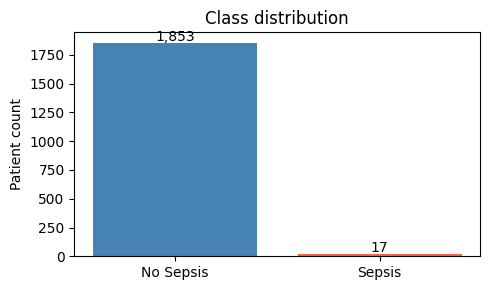

In [5]:
# ── STEP 3 — Class Imbalance Weight ──────────────────────────────────────
# scale_pos_weight = n_neg / n_pos reweights the CatBoost loss function
# so minority (sepsis) samples receive proportionally more gradient signal.

print('=' * 60)
print('STEP 3 — Class Imbalance Weight')
print('=' * 60)

y_all    = df_static[LABEL_COL]
X_all_df = df_static.drop(columns=[ID_COL, LABEL_COL])
if 'Unnamed: 0' in X_all_df.columns:
    X_all_df.drop(columns=['Unnamed: 0'], inplace=True)

n_pos = int(y_all.sum())
n_neg = int((y_all == 0).sum())
SPW   = n_neg / n_pos

print(f'  Negatives        : {n_neg:,}')
print(f'  Positives        : {n_pos:,}')
print(f'  scale_pos_weight : {SPW:.2f}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No Sepsis', 'Sepsis'], [n_neg, n_pos], color=['steelblue', 'tomato'])
ax.set_ylabel('Patient count')
ax.set_title('Class distribution')
for i, v in enumerate([n_neg, n_pos]):
    ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [6]:
# ── STEP 4 — Boruta Feature Selection ────────────────────────────────────
# Uses a balanced Random Forest so the imbalanced labels do not bias
# shadow-feature comparisons.

print('=' * 60)
print('STEP 4 — Boruta Feature Selection')
print('=' * 60)

rf_boruta = RandomForestClassifier(
    n_jobs=-1, class_weight='balanced', max_depth=5, random_state=SEED
)
boruta_sel = BorutaPy(
    rf_boruta, n_estimators='auto', verbose=1, random_state=SEED, max_iter=100
)

print('Running Boruta (may take a few minutes)...')
t0 = time.time()
boruta_sel.fit(X_all_df.values, y_all.values)
print(f'Done in {time.time()-t0:.1f}s')

confirmed  = X_all_df.columns[boruta_sel.support_].tolist()
tentative  = X_all_df.columns[boruta_sel.support_weak_].tolist()
print(f'\n  Confirmed ({len(confirmed)}) : {confirmed}')
print(f'  Tentative ({len(tentative)}) : {tentative}')

# Include tentative features if confirmed pool is small
boruta_features = confirmed + [f for f in tentative if f not in confirmed]
X_boruta        = X_all_df[boruta_features].copy()
print(f'  Working set ({len(boruta_features)})  : {boruta_features}')

STEP 4 — Boruta Feature Selection
Running Boruta (may take a few minutes)...
Iteration: 1 / 100
Iteration: 2 / 100
Iteration: 3 / 100
Iteration: 4 / 100
Iteration: 5 / 100
Iteration: 6 / 100
Iteration: 7 / 100
Iteration: 8 / 100
Iteration: 9 / 100
Iteration: 10 / 100
Iteration: 11 / 100
Iteration: 12 / 100
Iteration: 13 / 100
Iteration: 14 / 100
Iteration: 15 / 100
Iteration: 16 / 100
Iteration: 17 / 100
Iteration: 18 / 100
Iteration: 19 / 100
Iteration: 20 / 100
Iteration: 21 / 100
Iteration: 22 / 100
Iteration: 23 / 100
Iteration: 24 / 100
Iteration: 25 / 100
Iteration: 26 / 100
Iteration: 27 / 100
Iteration: 28 / 100
Iteration: 29 / 100
Iteration: 30 / 100
Iteration: 31 / 100
Iteration: 32 / 100
Iteration: 33 / 100
Iteration: 34 / 100
Iteration: 35 / 100
Iteration: 36 / 100
Iteration: 37 / 100
Iteration: 38 / 100
Iteration: 39 / 100
Iteration: 40 / 100
Iteration: 41 / 100
Iteration: 42 / 100
Iteration: 43 / 100
Iteration: 44 / 100
Iteration: 45 / 100
Iteration: 46 / 100
Iteration: 4

STEP 5 — Spearman Collinearity Check (threshold r > 0.8)


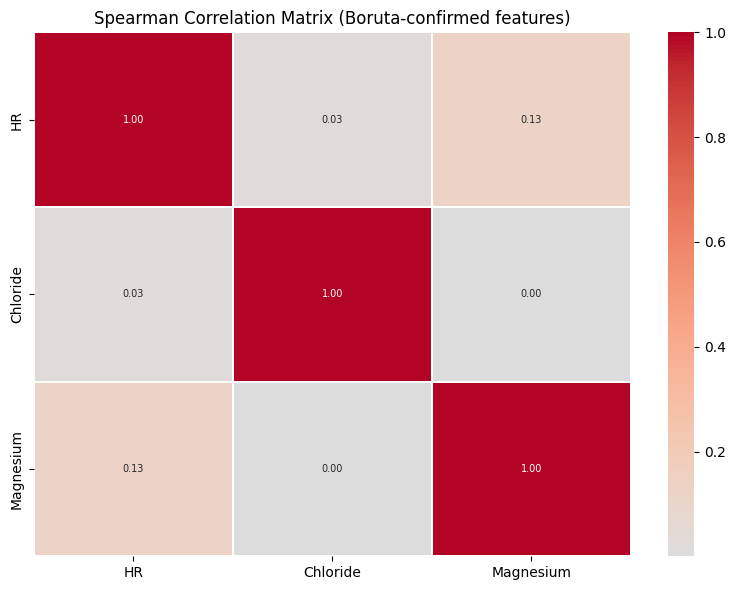

  Removed 0 collinear feature(s) : []
  Remaining (3)            : ['HR', 'Chloride', 'Magnesium']


In [7]:
# ── STEP 5 — Collinearity Check (Spearman r > 0.8) ───────────────────────

print('=' * 60)
print('STEP 5 — Spearman Collinearity Check (threshold r > 0.8)')
print('=' * 60)

corr = X_boruta.corr(method='spearman').abs()

fig, ax = plt.subplots(figsize=(max(8, len(boruta_features) // 2),
                                max(6, len(boruta_features) // 2)))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Spearman Correlation Matrix (Boruta-confirmed features)', fontsize=12)
plt.tight_layout()
plt.savefig('spearman_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

upper   = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = set()
for col in upper.columns:
    if col in to_drop:
        continue
    to_drop.update(upper.index[upper[col] > 0.8].tolist())

to_drop    = list(to_drop)
X_selected = X_boruta.drop(columns=to_drop, errors='ignore')
print(f'  Removed {len(to_drop)} collinear feature(s) : {to_drop}')
print(f'  Remaining ({X_selected.shape[1]})            : {X_selected.columns.tolist()}')

In [8]:
# ── STEP 6 — Train / Test Split (70 / 30, stratified) ────────────────────

print('=' * 60)
print('STEP 6 — Train / Test Split  70 / 30')
print('=' * 60)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_selected, y_all,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_all
)

# Recompute scale_pos_weight on training set only (correct practice)
n_pos_tr  = int(y_train.sum())
n_neg_tr  = int((y_train == 0).sum())
SPW_TRAIN = n_neg_tr / n_pos_tr

print(f'  Training set : {len(X_train_full):,}  (sepsis {y_train.mean():.2%})')
print(f'  Test set     : {len(X_test_full):,}   (sepsis {y_test.mean():.2%})')
print(f'  scale_pos_weight (train) : {SPW_TRAIN:.2f}')

STEP 6 — Train / Test Split  70 / 30
  Training set : 1,309  (sepsis 0.92%)
  Test set     : 561   (sepsis 0.89%)
  scale_pos_weight (train) : 108.08


In [9]:
# ── STEP 7 — Feature Reduction to Top 8 ──────────────────────────────────
# Priority: use the 8 target feature names if present in the dataset.
# Fallback: rank all features by CatBoost importance and take the top 8.

print('=' * 60)
print('STEP 7 — Feature Reduction to Top 8')
print('=' * 60)

# TARGET_8 = ['SOFA', 'SAPSII', 'Calcium', 'Chloride', 'WBC',
#              'SpO2', 'Temperature', 'MV']

TARGET_8 = ['SOFA', 'SAPSII', 'Calcium', 'Chloride', 'WBC', 'SpO2', 'Temperature', 'Age']

available = [f for f in TARGET_8 if f in X_selected.columns]
print(f'  Target features present : {available}  ({len(available)}/8)')

if len(available) >= 6:
    top_8   = available
    missing = [f for f in TARGET_8 if f not in available]
    if missing:
        print(f'  Filling {len(missing)} missing slot(s) from importance ranking...')
        tmp = CatBoostClassifier(
            iterations=ITERATIONS, learning_rate=LEARNING_RATE, depth=DEPTH,
            scale_pos_weight=SPW_TRAIN, random_seed=SEED, verbose=0
        )
        tmp.fit(X_train_full, y_train)
        imp_df = pd.DataFrame({'feature': X_train_full.columns,
                               'importance': tmp.feature_importances_
                               }).sort_values('importance', ascending=False)
        extras = [f for f in imp_df['feature'] if f not in top_8]
        top_8 += extras[:8 - len(top_8)]
else:
    print('  < 6 target features found → full importance ranking...')
    tmp = CatBoostClassifier(
        iterations=ITERATIONS, learning_rate=LEARNING_RATE, depth=DEPTH,
        scale_pos_weight=SPW_TRAIN, random_seed=SEED, verbose=0
    )
    tmp.fit(X_train_full, y_train)
    imp_df = pd.DataFrame({'feature': X_train_full.columns,
                           'importance': tmp.feature_importances_
                           }).sort_values('importance', ascending=False)
    print(imp_df.to_string(index=False))
    top_8  = imp_df.head(8)['feature'].tolist()

print(f'\n  Final 8 features : {top_8}')

X_train = X_train_full[top_8].copy()
X_test  = X_test_full[top_8].copy()
print(f'  X_train : {X_train.shape}  |  X_test : {X_test.shape}')

STEP 7 — Feature Reduction to Top 8
  Target features present : ['Chloride']  (1/8)
  < 6 target features found → full importance ranking...
  feature  importance
Magnesium   34.728967
       HR   33.586379
 Chloride   31.684654

  Final 8 features : ['Magnesium', 'HR', 'Chloride']
  X_train : (1309, 3)  |  X_test : (561, 3)


In [10]:
# ── STEP 8 — 10-Fold Cross-Validation ────────────────────────────────────

print('=' * 60)
print('STEP 8 — 10-Fold Stratified Cross-Validation')
print(f'  learning_rate={LEARNING_RATE} | depth={DEPTH} | iterations={ITERATIONS}')
print(f'  scale_pos_weight={SPW_TRAIN:.2f}')
print('=' * 60)

cv_model = CatBoostClassifier(
    iterations       = ITERATIONS,
    learning_rate    = LEARNING_RATE,
    depth            = DEPTH,
    scale_pos_weight = 20,
    eval_metric      = 'AUC',
    random_seed      = SEED,
    verbose          = 0
)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

print(f'Running {CV_FOLDS}-fold CV ...')
t0        = time.time()
cv_scores = cross_val_score(cv_model, X_train, y_train,
                            cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'Done in {time.time()-t0:.1f}s')
print(f'\n  CV AUC per fold : {np.round(cv_scores, 4)}')
print(f'  Mean CV AUC     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

STEP 8 — 10-Fold Stratified Cross-Validation
  learning_rate=0.1 | depth=10 | iterations=50
  scale_pos_weight=108.08
Running 10-fold CV ...
Done in 8.5s

  CV AUC per fold : [0.8538 0.6846 0.9154 0.9462 0.4385 0.7231 0.9385 0.7287 0.8062 1.    ]
  Mean CV AUC     : 0.8035 ± 0.1586


In [11]:
# ── STEP 9 — Final CatBoost Training ─────────────────────────────────────
# use_best_model=True checkpoints the iteration with the highest test AUC.

print('=' * 60)
print('STEP 9 — Final CatBoost Training')
print(f'  iterations={ITERATIONS} | learning_rate={LEARNING_RATE} | depth={DEPTH}')
print(f'  scale_pos_weight={SPW_TRAIN:.2f}')
print('=' * 60)

final_model = CatBoostClassifier(
    iterations       = ITERATIONS,
    learning_rate    = LEARNING_RATE,
    depth            = DEPTH,
    scale_pos_weight = 20,
    eval_metric      = 'AUC',
    random_seed      = SEED,
    verbose          = 10,
    use_best_model   = True
)

final_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=10
)

evals     = final_model.evals_result_
test_aucs = evals.get('validation', {}).get('AUC', [])
tr_aucs   = evals.get('learn',      {}).get('AUC', [])

print(f'\n  Best iteration : {final_model.best_iteration_} / {ITERATIONS}')
tr_proba = final_model.predict_proba(X_train)[:, 1]
print(f'  Train AUC      : {roc_auc_score(y_train, tr_proba):.4f}')
if test_aucs:
    bi = min(final_model.best_iteration_, len(test_aucs)) - 1
    print(f'  Test  AUC      : {test_aucs[bi]:.4f}')

STEP 9 — Final CatBoost Training
  iterations=50 | learning_rate=0.1 | depth=10
  scale_pos_weight=108.08
0:	test: 0.7357914	best: 0.7357914 (0)	total: 9.82ms	remaining: 481ms
10:	test: 0.5399281	best: 0.7357914 (0)	total: 80.4ms	remaining: 285ms
20:	test: 0.6086331	best: 0.7357914 (0)	total: 148ms	remaining: 204ms
30:	test: 0.5956835	best: 0.7357914 (0)	total: 243ms	remaining: 149ms
40:	test: 0.5910072	best: 0.7357914 (0)	total: 328ms	remaining: 72ms
49:	test: 0.5744604	best: 0.7357914 (0)	total: 397ms	remaining: 0us

bestTest = 0.7357913669
bestIteration = 0

Shrink model to first 1 iterations.

  Best iteration : 0 / 50
  Train AUC      : 0.9079
  Test  AUC      : 0.5745


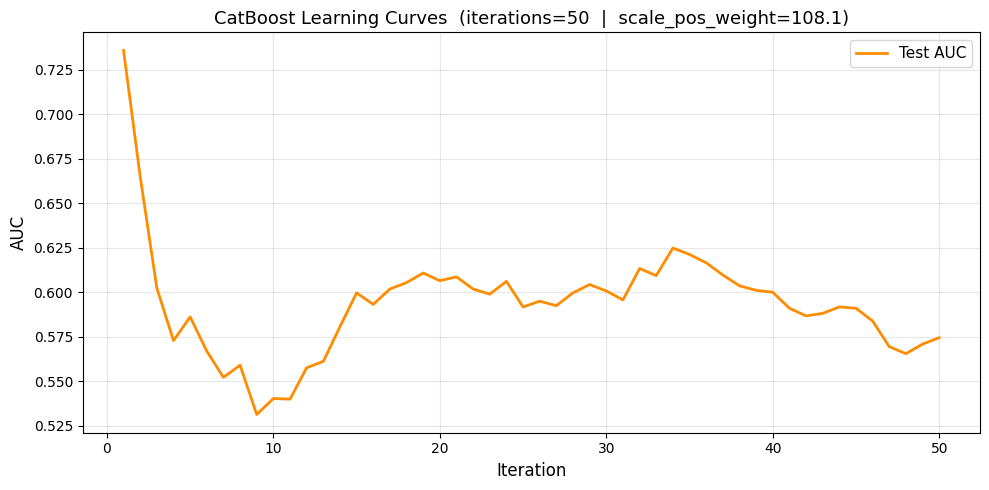

In [12]:
# ── STEP 10 — Learning Curves ─────────────────────────────────────────────

evals     = final_model.evals_result_
train_auc = evals.get('learn',      {}).get('AUC', [])
test_auc  = evals.get('validation', {}).get('AUC', [])
iters     = list(range(1, len(test_auc) + 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iters, test_auc, label='Test AUC',  color='darkorange', lw=2)
if len(train_auc) == len(test_auc):
    ax.plot(iters, train_auc, label='Train AUC', color='steelblue', lw=2)
bi = final_model.best_iteration_
if bi and 0 < bi <= len(test_auc):
    ax.axvline(bi, linestyle='--', color='gray', label=f'Best iter = {bi}')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('AUC',       fontsize=12)
ax.set_title(f'CatBoost Learning Curves  (iterations={ITERATIONS}  |  scale_pos_weight={SPW_TRAIN:.1f})',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

In [13]:
# ── STEP 11 — Evaluation Metrics + 95% CI (Bootstrap) ────────────────────
# Threshold: Youden index (maximises sensitivity + specificity).
# 95% CI: percentile bootstrap over N_BOOTSTRAP resamples of the test set.

print('=' * 60)
print('STEP 11 — Evaluation Metrics')
print('=' * 60)

y_proba = final_model.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)

# Youden-index threshold
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_test, y_proba)
youden_idx  = np.argmax(tpr_arr - fpr_arr)
best_thresh = thresh_arr[youden_idx]
y_pred      = (y_proba >= best_thresh).astype(int)
print(f'  Youden threshold : {best_thresh:.4f}')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy    = accuracy_score(y_test, y_pred)
precision   = precision_score(y_test, y_pred, zero_division=0)
f1          = f1_score(y_test, y_pred, zero_division=0)
fpr_val     = fp / (fp + tn)
fnr_val     = fn / (fn + tp)

# Bootstrap 95% CI for AUC
print(f'  Computing {N_BOOTSTRAP}-resample bootstrap CI for AUC...')
rng        = np.random.default_rng(SEED)
boot_aucs  = []
y_test_arr = np.array(y_test)
y_prob_arr = np.array(y_proba)
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, len(y_test_arr), len(y_test_arr))
    if y_test_arr[idx].sum() == 0 or y_test_arr[idx].sum() == len(idx):
        continue   # skip degenerate resamples
    boot_aucs.append(roc_auc_score(y_test_arr[idx], y_prob_arr[idx]))

ci_lo = float(np.percentile(boot_aucs, 2.5))
ci_hi = float(np.percentile(boot_aucs, 97.5))

# Results table
results = pd.DataFrame({
    'Metric': ['AUC (95% CI)', 'Sensitivity', 'Specificity',
               'Accuracy', 'Precision', 'F1-Score', 'FPR', 'FNR'],
    'Value' : [
        f'{auc:.4f}  ({ci_lo:.3f} – {ci_hi:.3f})',
        f'{sensitivity:.4f}', f'{specificity:.4f}',
        f'{accuracy:.4f}',    f'{precision:.4f}',
        f'{f1:.4f}',          f'{fpr_val:.4f}', f'{fnr_val:.4f}'
    ]
})
print()
print(results.to_string(index=False))

print()
print('─' * 48)
print(f'  AUC         : {auc:.4f}  95% CI [{ci_lo:.3f} – {ci_hi:.3f}]')
print(f'  Sensitivity : {sensitivity:.4f}')
print(f'  Specificity : {specificity:.4f}')
print(f'  Accuracy    : {accuracy:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  FPR         : {fpr_val:.4f}')
print(f'  FNR         : {fnr_val:.4f}')
print('─' * 48)

STEP 11 — Evaluation Metrics
  Youden threshold : 0.4713
  Computing 1000-resample bootstrap CI for AUC...

      Metric                   Value
AUC (95% CI) 0.7358  (0.491 – 0.954)
 Sensitivity                  0.8000
 Specificity                  0.6511
    Accuracy                  0.6524
   Precision                  0.0202
    F1-Score                  0.0394
         FPR                  0.3489
         FNR                  0.2000

────────────────────────────────────────────────
  AUC         : 0.7358  95% CI [0.491 – 0.954]
  Sensitivity : 0.8000
  Specificity : 0.6511
  Accuracy    : 0.6524
  Precision   : 0.0202
  F1-Score    : 0.0394
  FPR         : 0.3489
  FNR         : 0.2000
────────────────────────────────────────────────


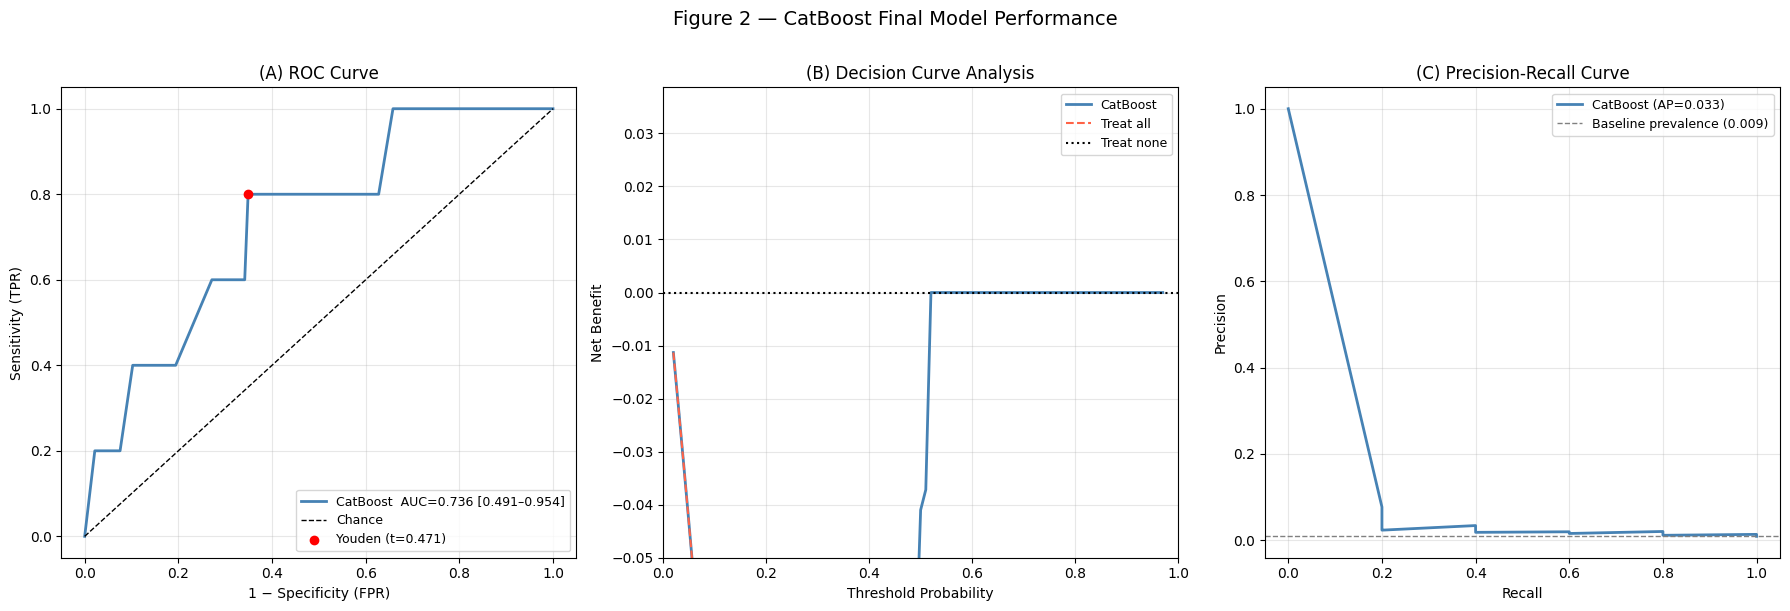

Saved → figure2_model_performance.png


In [14]:
# ── STEP 12 — Figure 2: ROC / DCA / Precision-Recall ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A — ROC
ax = axes[0]
ax.plot(fpr_arr, tpr_arr, color='steelblue', lw=2,
        label=f'CatBoost  AUC={auc:.3f} [{ci_lo:.3f}–{ci_hi:.3f}]')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
ax.scatter(fpr_arr[youden_idx], tpr_arr[youden_idx],
           color='red', zorder=5, label=f'Youden (t={best_thresh:.3f})')
ax.set_xlabel('1 − Specificity (FPR)')
ax.set_ylabel('Sensitivity (TPR)')
ax.set_title('(A) ROC Curve')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# B — Decision Curve Analysis
ax       = axes[1]
thresh_r = np.arange(0.02, 0.98, 0.01)
prev     = y_test.mean()
nb_model, nb_all = [], []
for t in thresh_r:
    yt   = (y_proba >= t).astype(int)
    tp_t = np.sum((yt == 1) & (y_test == 1))
    fp_t = np.sum((yt == 1) & (y_test == 0))
    n    = len(y_test)
    nb_model.append((tp_t / n) - (fp_t / n) * (t / (1 - t)))
    nb_all.append(prev - (1 - prev) * (t / (1 - t)))
ax.plot(thresh_r, nb_model, color='steelblue', lw=2,   label='CatBoost')
ax.plot(thresh_r, nb_all,   color='tomato',    lw=1.5, linestyle='--', label='Treat all')
ax.axhline(0, color='black', lw=1.5, linestyle=':', label='Treat none')
ax.set_xlim([0, 1])
valid_nb = [x for x in nb_all[:30] if np.isfinite(x)]
ax.set_ylim([-0.05, max(valid_nb) + 0.05] if valid_nb else [-0.05, 0.1])
ax.set_xlabel('Threshold Probability')
ax.set_ylabel('Net Benefit')
ax.set_title('(B) Decision Curve Analysis')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# C — Precision-Recall
ax = axes[2]
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
ax.plot(rec_arr, prec_arr, color='steelblue', lw=2,
        label=f'CatBoost (AP={ap:.3f})')
ax.axhline(prev, color='gray', linestyle='--', lw=1,
           label=f'Baseline prevalence ({prev:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('(C) Precision-Recall Curve')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Figure 2 — CatBoost Final Model Performance', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('figure2_model_performance.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → figure2_model_performance.png')

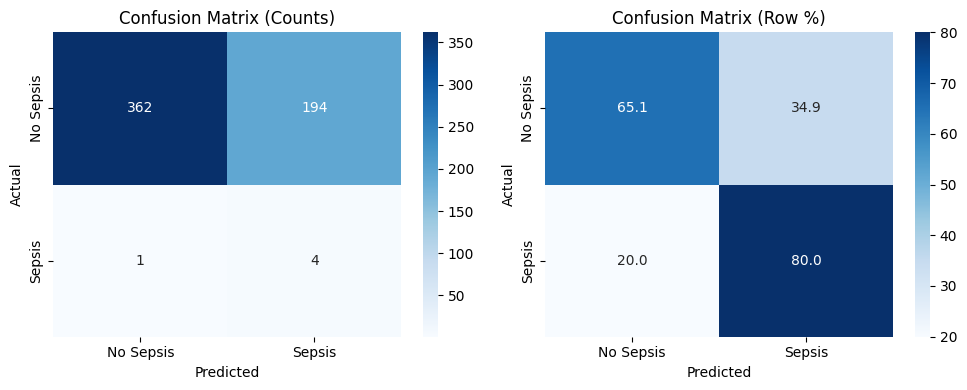

Saved → confusion_matrix.png


In [15]:
# ── STEP 13 — Confusion Matrix ────────────────────────────────────────────

cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, fmt, title in [
    (ax1, cm,     'd',   'Counts'),
    (ax2, cm_pct, '.1f', 'Row %')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['No Sepsis', 'Sepsis'],
                yticklabels=['No Sepsis', 'Sepsis'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix ({title})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved → confusion_matrix.png')

STEP 14 — SHAP Analysis


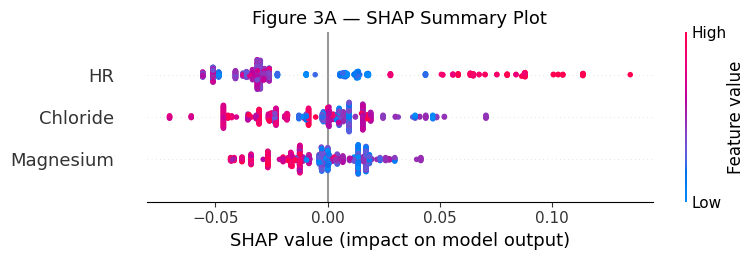

Saved → figure3A_shap_summary.png


In [16]:
# ── STEP 14 — SHAP Analysis: Figure 3A Summary (Swarm) Plot ──────────────

print('=' * 60)
print('STEP 14 — SHAP Analysis')
print('=' * 60)

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False, max_display=8)
plt.title('Figure 3A — SHAP Summary Plot', fontsize=13)
plt.tight_layout()
plt.savefig('figure3A_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → figure3A_shap_summary.png')

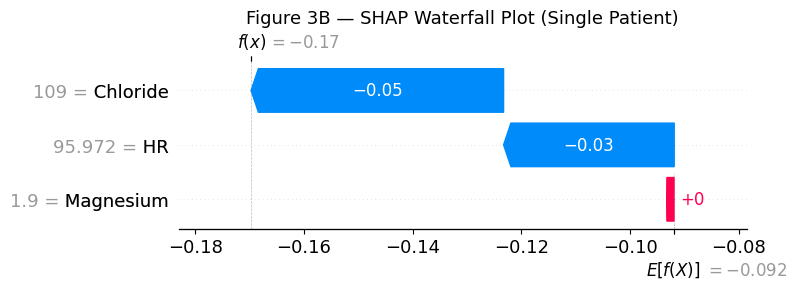

Saved → figure3B_shap_waterfall.png

Patient 0 — feature values:
  Magnesium              = 1.900
  HR                     = 95.972
  Chloride               = 109.000


In [17]:
# ── STEP 15 — SHAP: Figure 3B Waterfall Plot (single patient) ────────────
# Change patient_idx to inspect any patient in the test set.

patient_idx  = 0
patient_data = X_test.iloc[[patient_idx]]
sv_single    = explainer(patient_data)

plt.figure(figsize=(9, 5))
shap.waterfall_plot(sv_single[0], max_display=8, show=False)
plt.title('Figure 3B — SHAP Waterfall Plot (Single Patient)', fontsize=13)
plt.tight_layout()
plt.savefig('figure3B_shap_waterfall.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → figure3B_shap_waterfall.png')

print(f'\nPatient {patient_idx} — feature values:')
for col in X_test.columns:
    print(f'  {col:22s} = {patient_data[col].values[0]:.3f}')

In [18]:
# ── STEP 16 — Save Model & Outputs ───────────────────────────────────────

final_model.save_model('catboost_sepsis_final.cbm')

results.to_csv('model_results.csv', index=False)

with open('final_model_features.txt', 'w') as f:
    for feat in top_8:
        f.write(feat + '\n')

print('=' * 60)
print('PIPELINE COMPLETE — FINAL SUMMARY')
print('=' * 60)
print(f"""
Model             : CatBoost
learning_rate     : {LEARNING_RATE}
depth             : {DEPTH}
iterations        : {ITERATIONS}
scale_pos_weight  : {SPW_TRAIN:.2f}
Best iteration    : {final_model.best_iteration_} / {ITERATIONS}
Features ({len(top_8)})      : {top_8}

━━━ Results ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AUC         : {auc:.4f}  95% CI [{ci_lo:.3f} – {ci_hi:.3f}]
  Sensitivity : {sensitivity:.4f}
  Specificity : {specificity:.4f}
  Accuracy    : {accuracy:.4f}
  Precision   : {precision:.4f}
  F1-Score    : {f1:.4f}
  FPR         : {fpr_val:.4f}
  FNR         : {fnr_val:.4f}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print('Saved : catboost_sepsis_final.cbm')
print('Saved : model_results.csv')
print('Saved : final_model_features.txt')

PIPELINE COMPLETE — FINAL SUMMARY

Model             : CatBoost
learning_rate     : 0.1
depth             : 10
iterations        : 50
scale_pos_weight  : 108.08
Best iteration    : 0 / 50
Features (3)      : ['Magnesium', 'HR', 'Chloride']

━━━ Results ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AUC         : 0.7358  95% CI [0.491 – 0.954]
  Sensitivity : 0.8000
  Specificity : 0.6511
  Accuracy    : 0.6524
  Precision   : 0.0202
  F1-Score    : 0.0394
  FPR         : 0.3489
  FNR         : 0.2000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Saved : catboost_sepsis_final.cbm
Saved : model_results.csv
Saved : final_model_features.txt


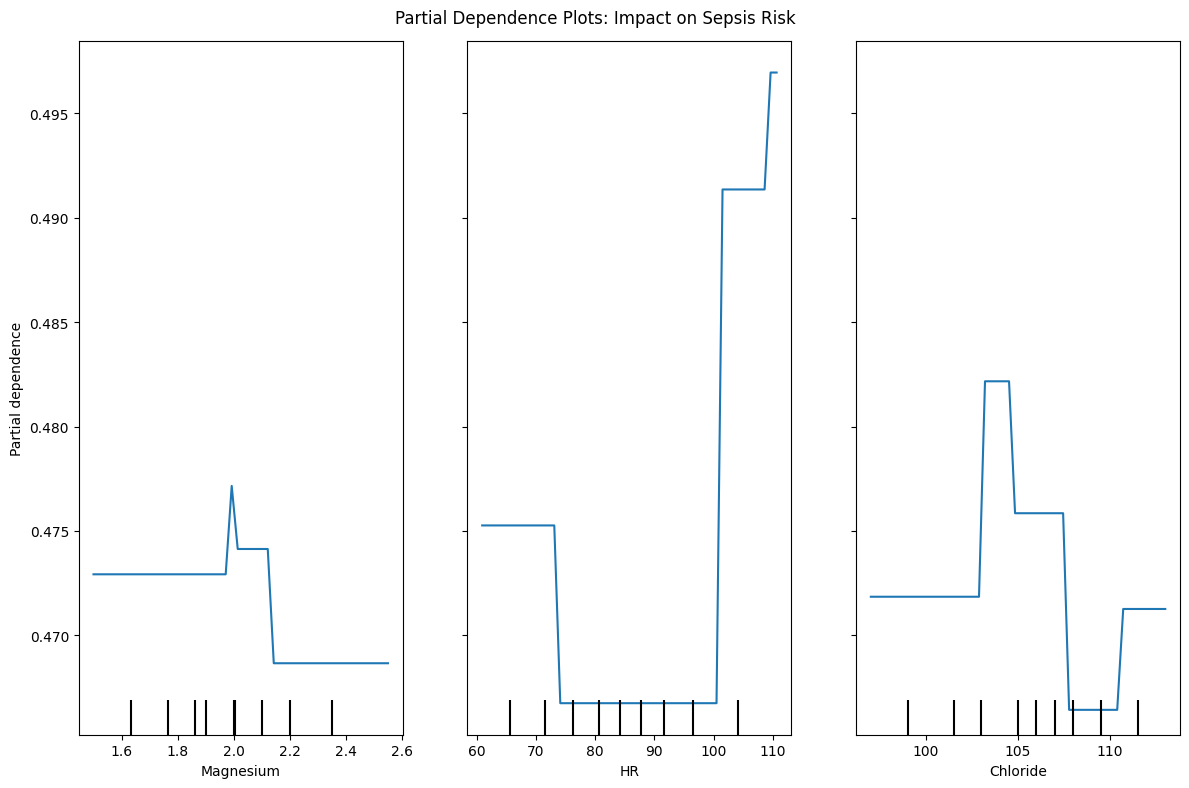

In [19]:
from sklearn.inspection import PartialDependenceDisplay

# Choose the top 4 most important features to visualize
features_to_plot = top_8[:4]

fig, ax = plt.subplots(figsize=(12, 8))
display = PartialDependenceDisplay.from_estimator(
    final_model,
    X_train,
    features=features_to_plot,
    grid_resolution=50,
    ax=ax
)
plt.suptitle("Partial Dependence Plots: Impact on Sepsis Risk")
plt.tight_layout()
plt.show()

In [20]:
# Install LIME for XAI analysis
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lime', '-q'], check=False)
print('✓ LIME installed')


✓ LIME installed


XAI 1 — Permutation Importance Analysis
Computing... (100 repeats, may take 1-2 minutes)

✓ Top Features by Permutation Importance:

  Feature  Importance      Std
 Chloride    0.177020 0.114271
       HR    0.155248 0.084861
Magnesium    0.055534 0.066321


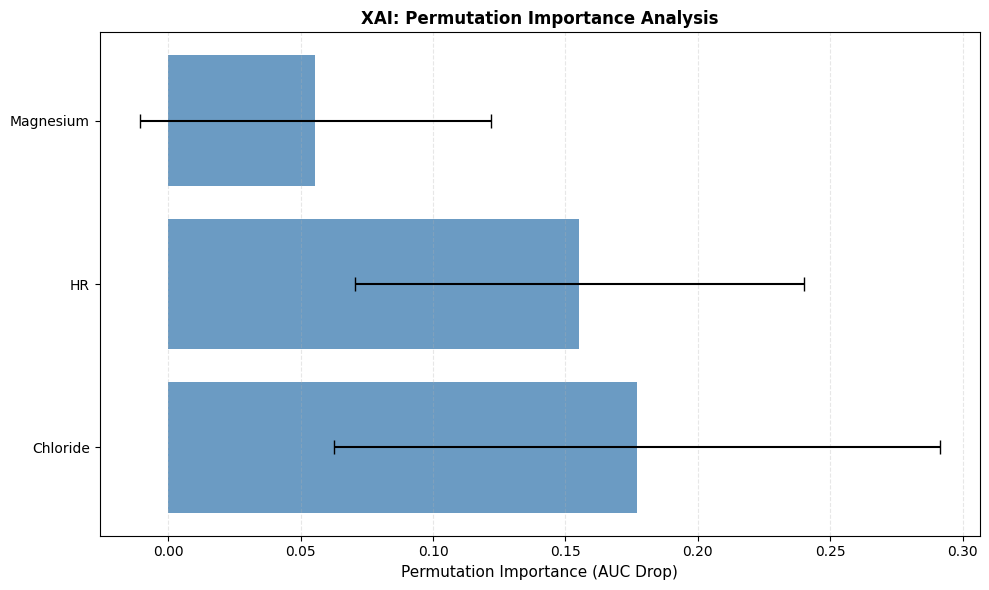

In [21]:
# ── XAI 1: Permutation Importance ──────────────────────────────────────────
from sklearn.inspection import permutation_importance
import numpy as np

print('='*60)
print('XAI 1 — Permutation Importance Analysis')
print('='*60)
print('Computing... (100 repeats, may take 1-2 minutes)')

perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=100,
    random_state=SEED,
    scoring='roc_auc',
    n_jobs=-1
)

perm_imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print('\n✓ Top Features by Permutation Importance:\n')
print(perm_imp_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(perm_imp_df))
ax.barh(y_pos, perm_imp_df['Importance'], xerr=perm_imp_df['Std'],
        color='steelblue', alpha=0.8, capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(perm_imp_df['Feature'])
ax.set_xlabel('Permutation Importance (AUC Drop)', fontsize=11)
ax.set_title('XAI: Permutation Importance Analysis', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


XAI 2 — LIME: Explaining Individual Predictions

Patient 1 (Index 0)
--------------------------------------------------
  Predicted Risk (Sepsis): 0.458
  True Label: No Sepsis
  Prediction: No Sepsis

  Top Contributing Features (for Sepsis risk):
    • HR > 94.00                               ↑ increases risk     (+0.0165)
    • 106.00 < Chloride <= 109.00              ↓ decreases risk     (-0.0044)
    • 1.80 < Magnesium <= 2.00                 ↑ increases risk     (+0.0015)


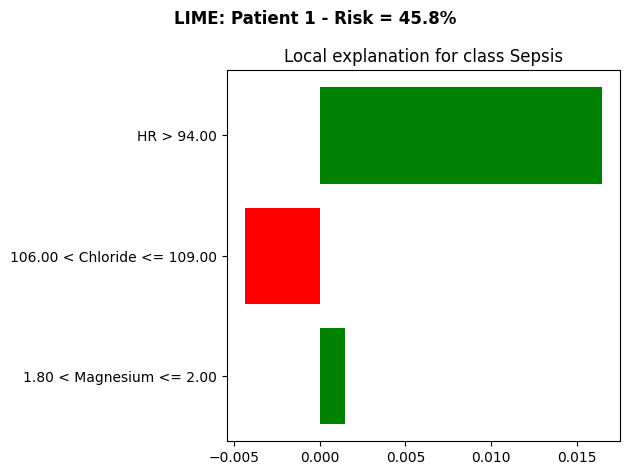


Patient 2 (Index 280)
--------------------------------------------------
  Predicted Risk (Sepsis): 0.462
  True Label: No Sepsis
  Prediction: No Sepsis

  Top Contributing Features (for Sepsis risk):
    • 84.16 < HR <= 94.00                      ↓ decreases risk     (-0.0102)
    • 102.50 < Chloride <= 106.00              ↑ increases risk     (+0.0086)
    • Magnesium > 2.15                         ↓ decreases risk     (-0.0042)


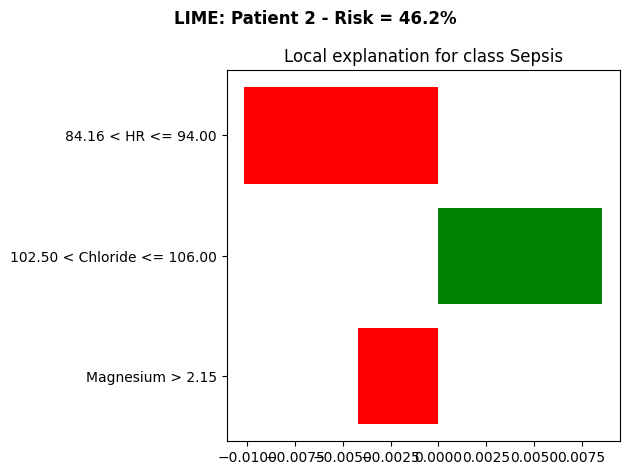


Patient 3 (Index 560)
--------------------------------------------------
  Predicted Risk (Sepsis): 0.458
  True Label: No Sepsis
  Prediction: No Sepsis

  Top Contributing Features (for Sepsis risk):
    • 73.70 < HR <= 84.16                      ↓ decreases risk     (-0.0098)
    • Chloride > 109.00                        ↓ decreases risk     (-0.0055)
    • 1.80 < Magnesium <= 2.00                 ↑ increases risk     (+0.0011)


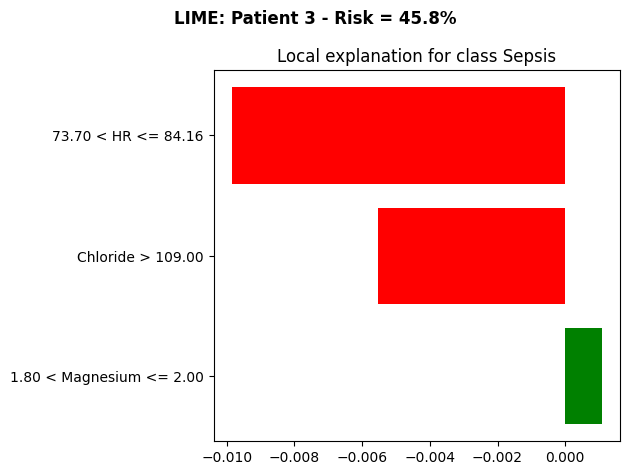


✓ LIME analysis complete


In [23]:
import lime
import lime.lime_tabular

print('='*60)
print('XAI 2 — LIME: Explaining Individual Predictions')
print('='*60)

# Initialize LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Sepsis', 'Sepsis'],
    mode='classification',
    random_state=SEED
)

# Analyze 3 patients
patient_indices = [0, len(X_test)//2, len(X_test)-1]

for idx, patient_idx in enumerate(patient_indices):
    print(f'\nPatient {idx+1} (Index {patient_idx})')
    print('-' * 50)

    patient_data = X_test.iloc[patient_idx].values
    pred_proba = final_model.predict_proba(X_test.iloc[[patient_idx]])[0]

    print(f'  Predicted Risk (Sepsis): {pred_proba[1]:.3f}')
    print(f'  True Label: {"Sepsis" if y_test.iloc[patient_idx] == 1 else "No Sepsis"}')
    print(f'  Prediction: {"Sepsis" if pred_proba[1] > 0.5 else "No Sepsis"}\n')

    exp = explainer_lime.explain_instance(
        patient_data,
        final_model.predict_proba,
        num_features=min(8, len(X_train.columns)),
        top_labels=2 # Changed from 1 to 2 to get explanations for both classes
    )

    # Check if explanation for label 1 (Sepsis) is available
    if 1 in exp.available_labels():
        exp_list = exp.as_list(label=1)
        print('  Top Contributing Features (for Sepsis risk):')
        for feature_desc, weight in exp_list:
            direction = '↑ increases risk' if weight > 0 else '↓ decreases risk'
            print(f'    • {feature_desc:40s} {direction:20s} ({weight:+.4f})')

        # Visualize LIME
        fig = exp.as_pyplot_figure(label=1)
        fig.suptitle(f'LIME: Patient {idx+1} - Risk = {pred_proba[1]:.1%}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'  LIME explanation for Sepsis (label 1) not available for Patient {idx+1}.')
        print('  This usually happens when the model strongly predicts "No Sepsis" for this patient,')
        print('  and LIME focuses its explanation on the predicted class (No Sepsis).')

print('\n✓ LIME analysis complete')


XAI 3 — Risk Stratification: Comparing Risk Drivers

HIGH RISK Patient
--------------------------------------------------
  Predicted Risk: 51.8%
  True Label: No Sepsis

LOW RISK Patient
--------------------------------------------------
  Predicted Risk: 45.8%
  True Label: No Sepsis


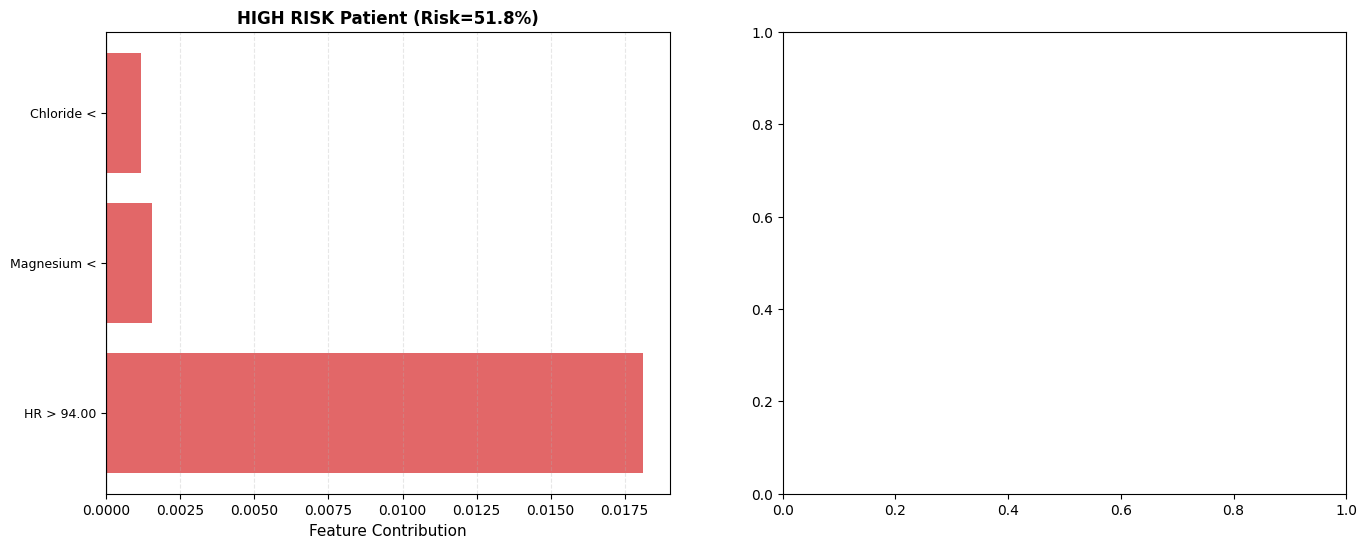

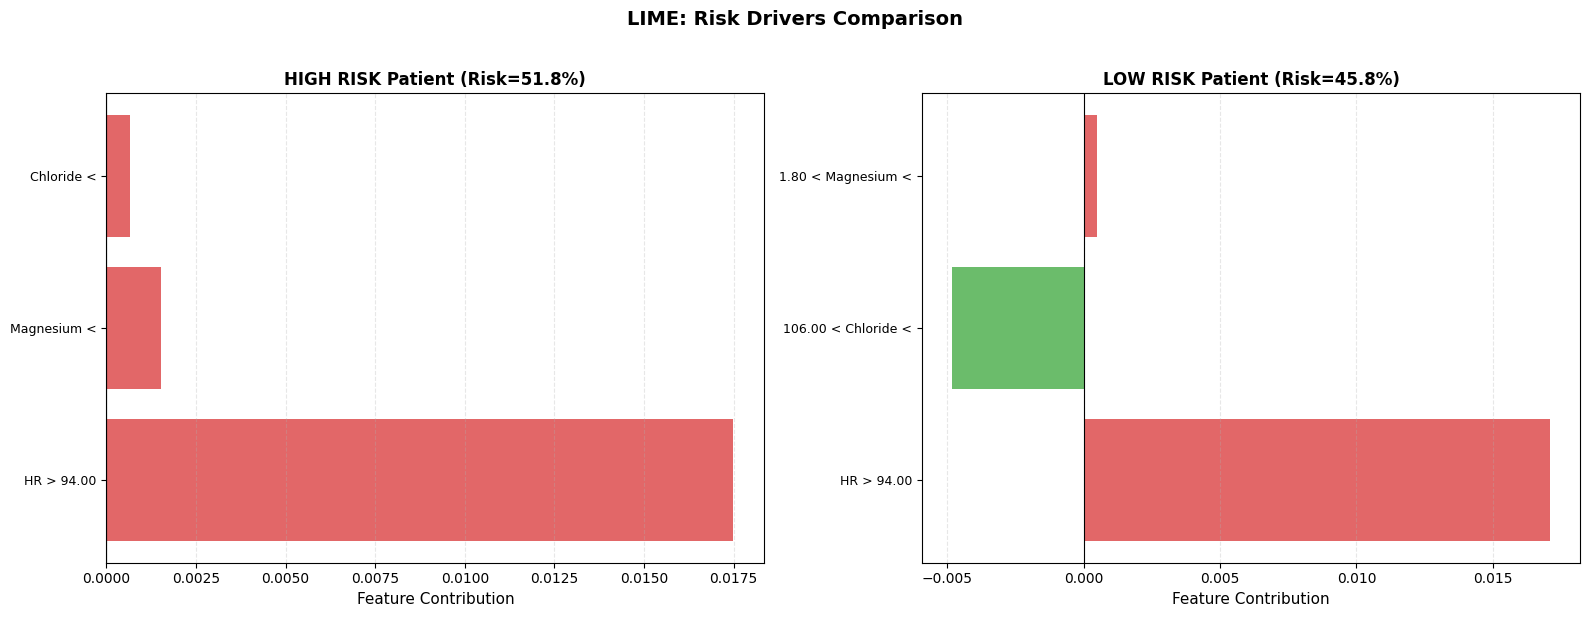


✓ Risk stratification analysis complete


In [26]:
# ── XAI 3: LIME Risk Stratification (High vs Low Risk) ────────────────────
print('='*60)
print('XAI 3 — Risk Stratification: Comparing Risk Drivers')
print('='*60)

y_pred_proba_all = final_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argsort(y_pred_proba_all)[-1]
low_risk_idx = np.argsort(y_pred_proba_all)[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, patient_idx, risk_label in [(axes[0], high_risk_idx, 'HIGH RISK'),
                                      (axes[1], low_risk_idx, 'LOW RISK')]:
    patient_data = X_test.iloc[patient_idx].values
    pred_proba = final_model.predict_proba(X_test.iloc[[patient_idx]])[0]

    print(f'\n{risk_label} Patient')
    print('-' * 50)
    print(f'  Predicted Risk: {pred_proba[1]:.1%}')
    print(f'  True Label: {"Sepsis" if y_test.iloc[patient_idx] == 1 else "No Sepsis"}')

    exp = explainer_lime.explain_instance(
        patient_data,
        final_model.predict_proba,
        num_features=min(8, len(X_train.columns)),
        top_labels=2 # Changed from 1 to 2 to get explanations for both classes
    )

    # Check if explanation for label 1 (Sepsis) is available
    if 1 in exp.available_labels():
        exp_list = exp.as_list(label=1)
        feature_names = [item[0].split('=')[0].strip() for item in exp_list]
        feature_weights = [item[1] for item in exp_list]
        colors = ['#d62728' if w > 0 else '#2ca02c' for w in feature_weights]

        y_pos = np.arange(len(feature_names))
        ax.barh(y_pos, feature_weights, color=colors, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(feature_names, fontsize=9)
        ax.set_xlabel('Feature Contribution', fontsize=11)
        ax.set_title(f'{risk_label} Patient (Risk={pred_proba[1]:.1%})', fontsize=12, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
    else:
        ax.text(0.5, 0.5, 'Sepsis explanation not available', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(f'{risk_label} Patient (Risk={pred_proba[1]:.1%})', fontsize=12, fontweight='bold')
        print(f'  LIME explanation for Sepsis (label 1) not available for {risk_label} Patient.')
        print('  This usually happens when the model strongly predicts "No Sepsis" for this patient,')
        print('  and LIME focuses its explanation on the predicted class (No Sepsis).')

plt.suptitle('LIME: Risk Drivers Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n✓ Risk stratification analysis complete')
